**practica #3:**

**Series de Fourier: magnitud y fase**

**presentado por:**
Karly Tarazona, Luis Montoya 



**procedimiento:**

a) Construya una señal cuadrada periódica, definiendo su frecuencia fundamental, amplitud y número de muestras.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [12]:
f0 = 5          # Frecuencia fundamental [Hz]
A = 1           # Amplitud
N = 1000        # Número de muestras

T0 = 1 / f0     # Periodo fundamental

t = np.linspace(0, 2*T0, N, endpoint=False)
x_cuadrada = A * np.sign(np.sin(2 * np.pi * f0 * t))




b) Construya una señal triangular periódica, con la misma frecuencia fundamental, amplitud y número de muestras que la señal anterior.

In [14]:
x_triangular = A * (2 / np.pi) * np.arcsin(
    np.sin(2 * np.pi * f0 * t))

c) Grafique ambas señales en el dominio del tiempo.

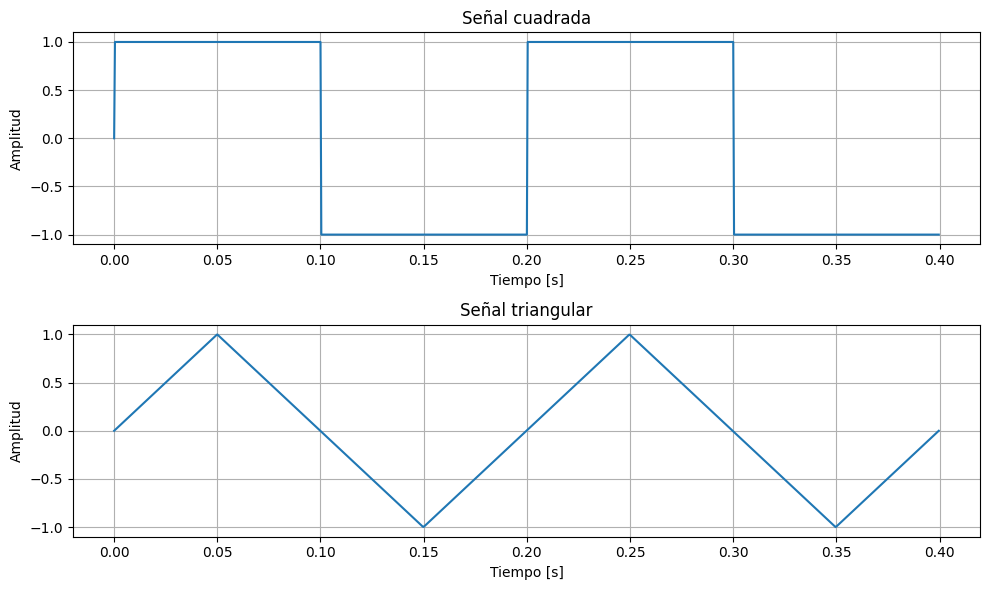

In [13]:
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(t, x_cuadrada)
plt.title("Señal cuadrada")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(t, x_triangular)
plt.title("Señal triangular")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.grid(True)

plt.tight_layout()
plt.show()

d) Cree una función que reciba una señal periódica, y devuelva sus coeficientes de la serie de Fourier (forma exponencial), calculados mediante NumPy.

In [16]:
def coeficientes_fourier(x):
    N = len(x)
    
    # Transformada rápida de Fourier
    C = np.fft.fft(x)
    
    # Normalización
    C = C / N
    
    # Reorganizar las frecuencias
    C = np.fft.fftshift(C)
    
    return C



e) Aplique la función anterior a la señal cuadrada y a la señal triangular, y obtenga sus respectivos coeficientes.

In [17]:
C_cuadrada = coeficientes_fourier(x_cuadrada)

C_triangular = coeficientes_fourier(x_triangular)

print(C_cuadrada)
print(C_triangular)

[ 0.001+0.00000000e+00j  0.001+0.00000000e+00j -0.003+2.51330720e-05j
  0.001+0.00000000e+00j  0.001+0.00000000e+00j  0.001+0.00000000e+00j
 -0.003+7.54071548e-05j  0.001+0.00000000e+00j  0.001+0.00000000e+00j
  0.001+0.00000000e+00j -0.003+1.25705064e-04j  0.001+0.00000000e+00j
  0.001+0.00000000e+00j  0.001+0.00000000e+00j -0.003+1.76042718e-04j
  0.001+0.00000000e+00j  0.001+0.00000000e+00j  0.001+0.00000000e+00j
 -0.003+2.26436085e-04j  0.001+0.00000000e+00j  0.001+0.00000000e+00j
  0.001+0.00000000e+00j -0.003+2.76901203e-04j  0.001+0.00000000e+00j
  0.001+0.00000000e+00j  0.001+0.00000000e+00j -0.003+3.27454202e-04j
  0.001+0.00000000e+00j  0.001+0.00000000e+00j  0.001+0.00000000e+00j
 -0.003+3.78111325e-04j  0.001+0.00000000e+00j  0.001+0.00000000e+00j
  0.001+0.00000000e+00j -0.003+4.28888945e-04j  0.001+0.00000000e+00j
  0.001+0.00000000e+00j  0.001+0.00000000e+00j -0.003+4.79803592e-04j
  0.001+0.00000000e+00j  0.001+0.00000000e+00j  0.001+0.00000000e+00j
 -0.003+5.30871971e-

f) Cree una función que reciba un conjunto de coeficientes de Fourier y grafique el espectro de magnitud y el espectro de fase correspondientes.

In [19]:
frecuencias = np.fft.fftshift(
    np.fft.fftfreq(N, d=T0/N))

def graficar_espectros(C, frecuencias, titulo):
    
    # Calcular magnitud y fase
    magnitud = np.abs(C)
    fase = np.angle(C)
    
    # Crear figura
    plt.figure(figsize=(10, 6))
    
    # -------------------------
    # Espectro de magnitud
    # -------------------------
    plt.subplot(2, 1, 1)
    plt.stem(frecuencias, magnitud)
    plt.title("Espectro de magnitud - " + titulo)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("|C_k|")
    plt.grid(True)
    
    # -------------------------
    # Espectro de fase
    # -------------------------
    plt.subplot(2, 1, 2)
    plt.stem(frecuencias, fase)
    plt.title("Espectro de fase - " + titulo)
    plt.xlabel("Frecuencia [Hz]")
    plt.ylabel("Fase [rad]")
    plt.grid(True)
    
    # Ajustar espacios
    plt.tight_layout()
    
    # Mostrar
    plt.show()


g) Grafique los espectros de magnitud y fase de la señal cuadrada y de la señal triangular.

In [ ]:
graficar_espectros(
    C_cuadrada,
    frecuencias,
    "Señal cuadrada"
)

graficar_espectros(
    C_triangular,
    frecuencias,
    "Señal triangular"
)

h) Cree una función que reconstruya una señal a partir de una suma de senos (armónicos), recibiendo como parámetros los coeficientes de Fourier y el número de armónicos a utilizar.

In [20]:
def reconstruir_señal(C, t, f0, num_armonicos):
    
    N = len(C)
    
    # Índices de los coeficientes
    k = np.arange(-N//2, N//2)
    
    # Frecuencia angular fundamental
    w0 = 2 * np.pi * f0
    
    # Señal reconstruida
    x_reconstruida = np.zeros(len(t), dtype=complex)
    
    # Seleccionar los armónicos
    for i in range(len(k)):
        
        if abs(k[i]) <= num_armonicos:
            
            x_reconstruida += C[i] * np.exp(
                1j * k[i] * w0 * t
            )
    
    # Como la señal original es real,
    # tomamos la parte real
    return np.real(x_reconstruida)

i) Reconstruya la señal cuadrada y la señal triangular utilizando N = 1, 3, 5, 20 y 50 armónicos, y grafique cada reconstrucción junto con la señal original.

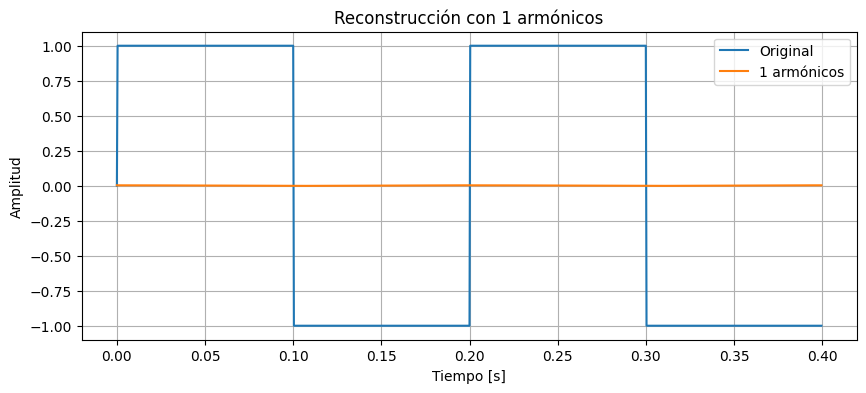

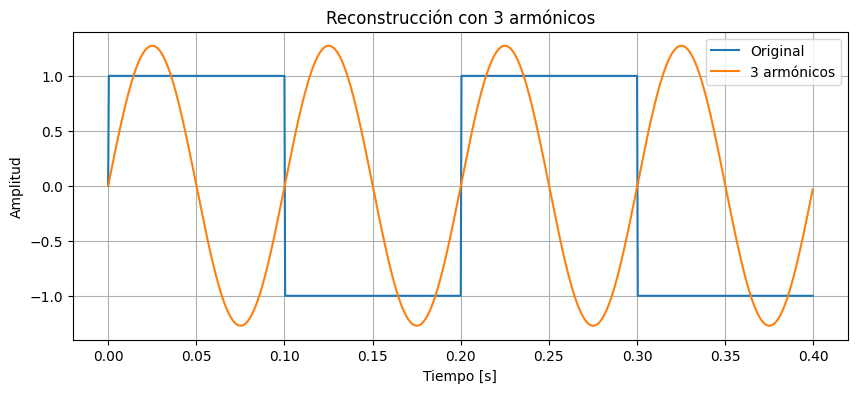

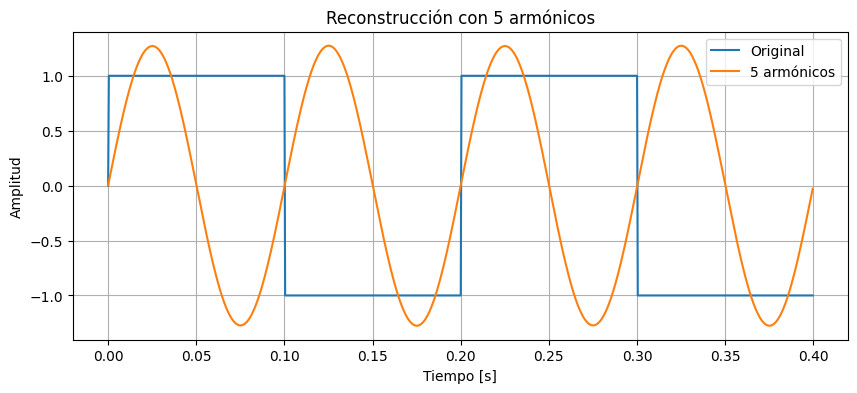

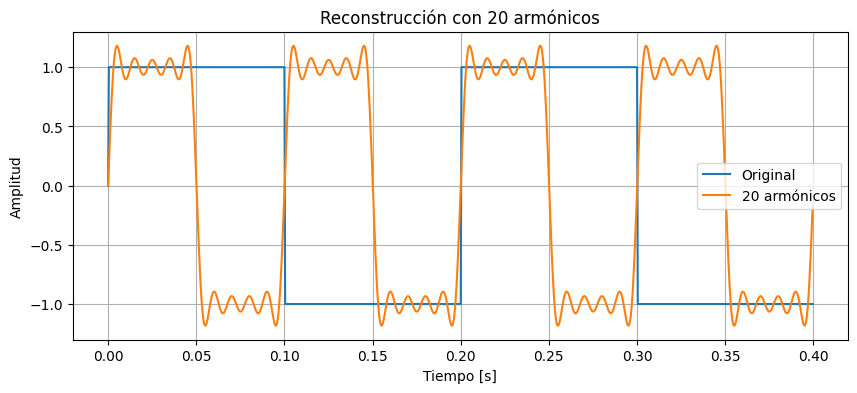

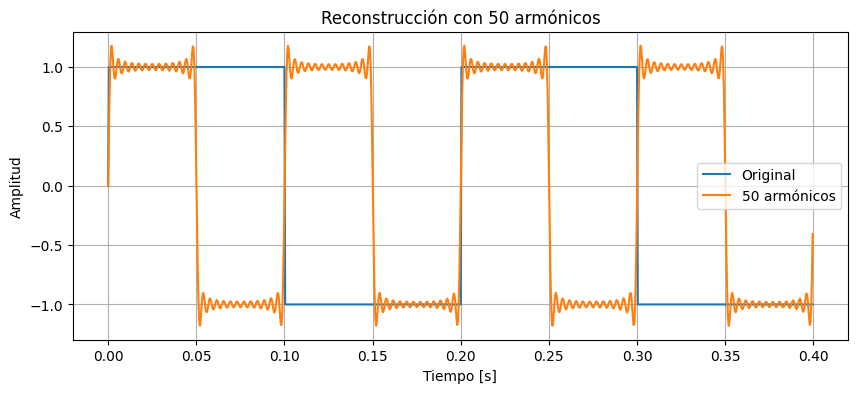

In [22]:
armonicos = [1, 3, 5, 20, 50]

for n in armonicos:
    
    x_reconstruida = reconstruir_señal(
        C_cuadrada,
        t,
        f0,
        n
    )
    
    plt.figure(figsize=(10, 4))
    
    plt.plot(t, x_cuadrada, label="Original")
    plt.plot(t, x_reconstruida, label=f"{n} armónicos")
    
    plt.title(f"Reconstrucción con {n} armónicos")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    
    plt.show()

    armonicos = [1, 3, 5, 20, 50]

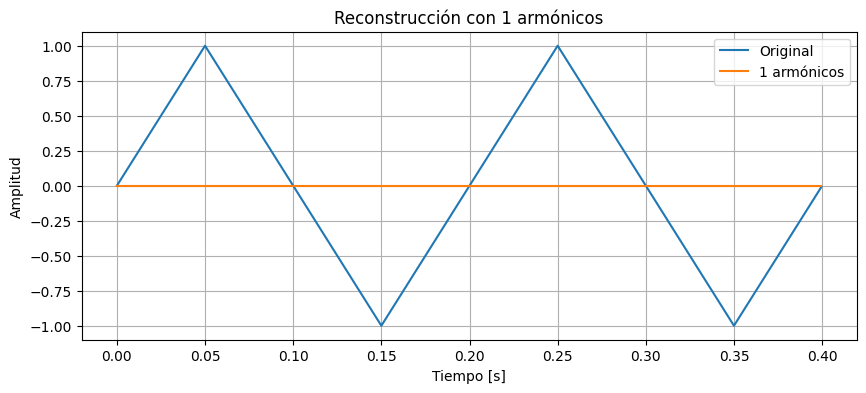

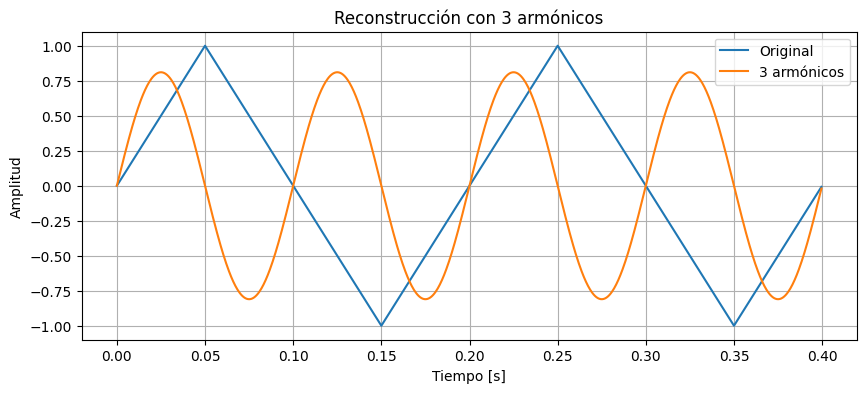

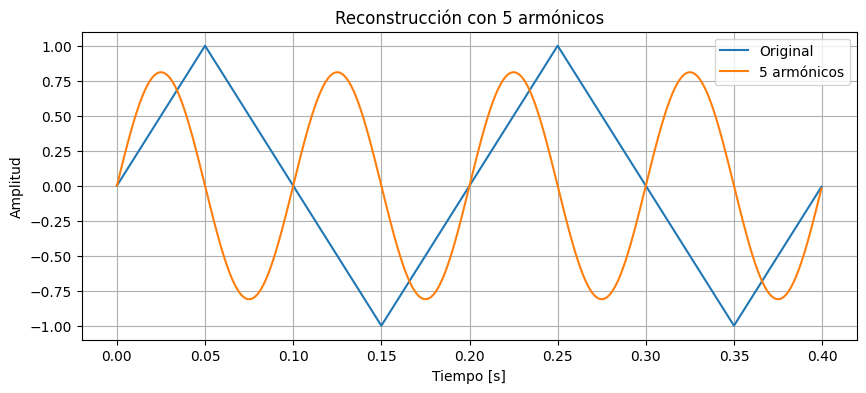

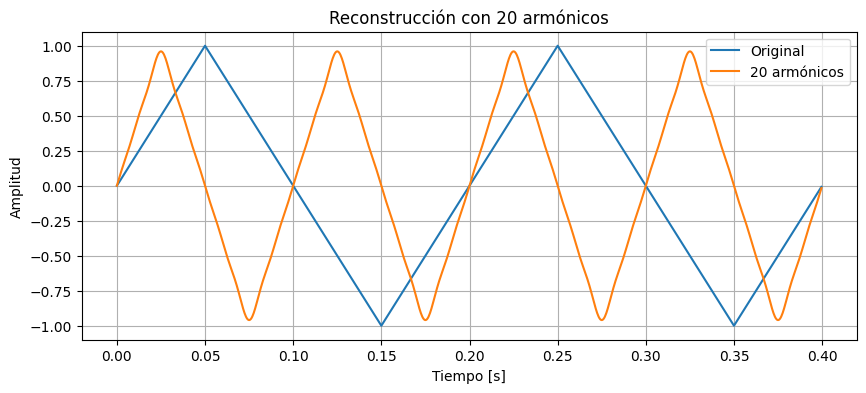

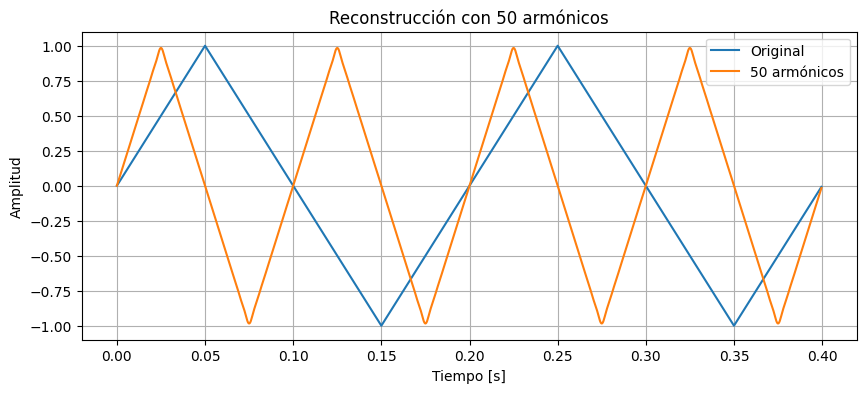

In [23]:


for n in armonicos:
    
    x_reconstruida = reconstruir_señal(
        C_triangular,
        t,
        f0,
        n
    )
    
    plt.figure(figsize=(10, 4))
    
    plt.plot(t, x_triangular, label="Original")
    plt.plot(t, x_reconstruida, label=f"{n} armónicos")
    
    plt.title(f"Reconstrucción con {n} armónicos")
    plt.xlabel("Tiempo [s]")
    plt.ylabel("Amplitud")
    plt.grid(True)
    plt.legend()
    
    plt.show()

j) Consulte, analice y describa el fenómeno de Gibbs observado en las reconstrucciones de la señal cuadrada.